In [5]:
from training.Train_validate import Train_Validate_CNN
from training.Testing_M5_Network_original import Test_model_accuracy_original, Output_Test_Error_Samples
from training.Bcolors import bcolors
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("number of GPUs:", torch.cuda.device_count())
PROJECT_ROOT = Path.cwd().parents[1]
DATASET_DIR = PROJECT_ROOT/"Dataset"
MODEL_DIR = PROJECT_ROOT/"models"
FIG_DIR = PROJECT_ROOT/"figs"
print(PROJECT_ROOT)
print(DATASET_DIR)
print(MODEL_DIR)
print(FIG_DIR)
Folder_name_list_of_dataset = ['Synthesized_Dataset/Training_data', 'Synthesized_Dataset/Validate_data', 'Synthesized_Dataset/Testing_data']
Folder_name_list_of_dataset = [DATASET_DIR/i for i in Folder_name_list_of_dataset]
File_sheet = "Hard_Index.csv"
MODEL_PTH = MODEL_DIR/"M6_res_Synthetic.pth"

number of GPUs: 4
/home/rkobayashi/anc/GFANC-custom
/home/rkobayashi/anc/GFANC-custom/Dataset
/home/rkobayashi/anc/GFANC-custom/models
/home/rkobayashi/anc/GFANC-custom/figs


Epoch 1
Learning rate: 0.01
Training Loss: 0.2817478872835636 Training Accuracy: 0.268
Validation Loss : 1.217364889383316 Validation Accuracy : 0.002
Trained feed forward net saved at M6_res_Synthetic.pth
----------------------------------
Epoch 2
Learning rate: 0.01
Training Loss: 0.12161956168711185 Training Accuracy: 0.48100000000000004
Validation Loss : 0.5606822609901428 Validation Accuracy : 0.13500000000000006
Trained feed forward net saved at M6_res_Synthetic.pth
----------------------------------
Epoch 3
Learning rate: 0.01
Training Loss: 0.09649240281432866 Training Accuracy: 0.555
Validation Loss : 0.08935953080654144 Validation Accuracy : 0.61
Trained feed forward net saved at M6_res_Synthetic.pth
----------------------------------
Epoch 4
Learning rate: 0.01
Training Loss: 0.07408448364585637 Training Accuracy: 0.6649999999999999
Validation Loss : 0.06418043095618486 Validation Accuracy : 0.73
Trained feed forward net saved at M6_res_Synthetic.pth
------------------------

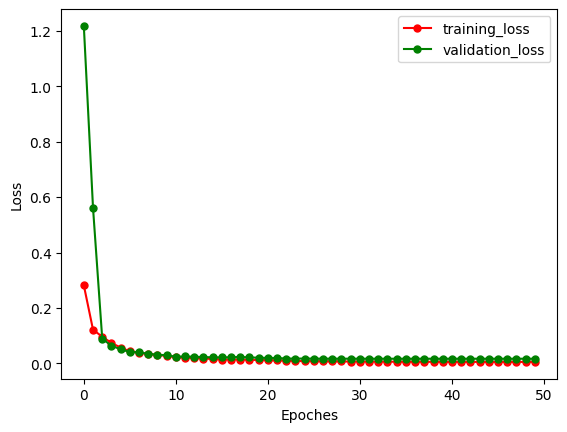

In [ ]:
acc_train, acc_validate, train_loss_epochs, validate_loss_epochs = Train_Validate_CNN(TRIAN_DATASET_FILE=Folder_name_list_of_dataset[0]
                                                        , VALIDATION_DATASET_FILE=Folder_name_list_of_dataset[1]
                                                        , MODEL_PTH=MODEL_PTH, File_sheet=File_sheet, BATCH_SIZE=50)
plt.plot(np.arange(len(train_loss_epochs)),train_loss_epochs, marker='.', markersize=10, color='r',label='training_loss')
plt.plot(np.arange(len(validate_loss_epochs)),validate_loss_epochs, marker='.', markersize=10, color='g',label='validation_loss')
plt.ylabel('Loss')
plt.xlabel('Epoches')
plt.legend()
plt.savefig(FIG_DIR/'Training_loss.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

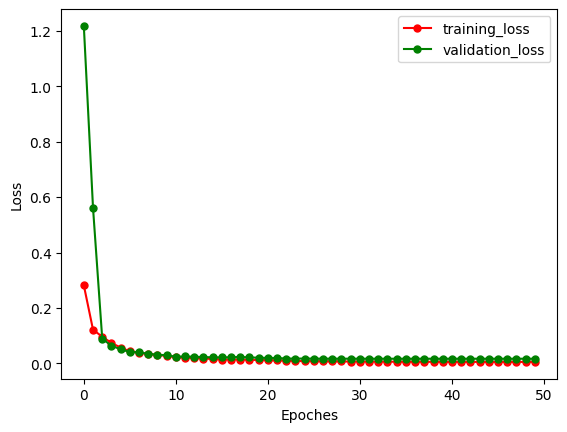

In [ ]:
plt.plot(np.arange(len(train_loss_epochs)),train_loss_epochs, marker='.', markersize=10, color='r',label='training_loss')
plt.plot(np.arange(len(validate_loss_epochs)),validate_loss_epochs, marker='.', markersize=10, color='g',label='validation_loss')
plt.ylabel('Loss')
plt.xlabel('Epoches')
plt.legend()
plt.savefig(FIG_DIR/'Training_loss.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [4]:
# Output the test error samples by the pre-trained network
if os.path.exists(MODEL_PTH):
    acc = Output_Test_Error_Samples(TESTING_DATASET_FILE=Folder_name_list_of_dataset[2]
                                      , MODLE_PTH=MODEL_PTH, File_sheet=File_sheet)
    repot = bcolors.OKGREEN  + f' The accuracy on testing datast is {acc}' + bcolors.ENDC
    print(repot)
else:
    print(bcolors.FAIL + MODEL_PTH + ' does not exsit !' + bcolors.ENDC)

length of testing_dataset:1000
853_Frequency_from_6449_to_7481_10s_Hz.wav [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
919_Frequency_from_469_to_7647_10s_Hz.wav [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
464_Frequency_from_7914_to_7980_10s_Hz.wav [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
796_Frequency_from_1617_to_5037_10s_Hz.wav [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0] [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
274_Frequency_from_1130_to_1499_10s_Hz.wav [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] [0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
205_Frequency_from_2686_to_4034_10s_Hz.wav [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
410_Frequency_from_1107_to_2188_10s_Hz.wav [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
628_Frequency_from_3723_t